In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [36]:
import torch 

train_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

X_train_np = train_df.drop(columns=["label"]).values
y_train_np = train_df["label"].values
X_test_np = test_df.values

X_train = torch.tensor(X_train_np, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0 

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: torch.Size([42000, 1, 28, 28])
y_train shape: torch.Size([42000])
X_test shape: torch.Size([28000, 1, 28, 28])


/tmp/ipykernel_48/546712037.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0


In [38]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test)

train_dataset, test_dataset

(<torch.utils.data.dataset.TensorDataset at 0x7a37f94c87c0>,
 <torch.utils.data.dataset.TensorDataset at 0x7a37ed6cd8c0>)

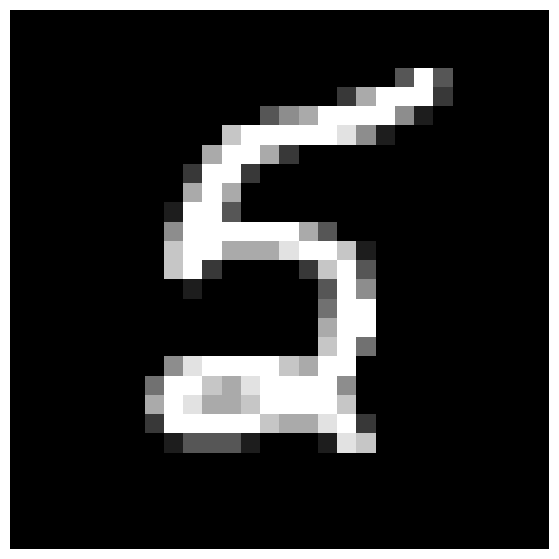

In [58]:
import random 
import matplotlib.pyplot as plt 

random.seed(2026)

random_index = random.randint(0, len(train_dataset) - 1)
img, label = train_dataset[random_index] 

plt.figure(figsize=(10, 7))
plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off");

In [ ]:
train_dataloader = TrainDataloader()